<a href="https://colab.research.google.com/github/vshalisko/Estudio_ambiental_Naylet_fork/blob/main/Colima/NCL_NDVI_Graficas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MARCO GEOESPACIAL

## Área Natural Protegida: Parque Estatal Bosque Mesofilo Nevado de Colima

**Tesista:** Naylet Hernández Sánchez  
**Director:** Viacheslav Shalisko  
**Doctorado:** Geografía y Ordenamiento Territorial  
**Proyecto:** "Evaluación comparativa de la pérdida de hábitat en territorios protegidos y no protegidos de Jalisco mediante percepción remota y aprendizaje automatizado en el periodo 2000-2020".

## Descripción del área

##Definir Variables

In [1]:
#  DEFINICIÓN DE VARIABLES

# Prefijo del área
PREFIJO     = 'NCL'

# Nombre del área
NOMBRE      = 'Nevado_Colima'

#RUTA_GPKG  = '/content/drive/MyDrive/ANP/ParqueEstatalBosqueMesofiloNevadodeColima.gpkg'
RUTA_GPKG  = '/content/drive/MyDrive/Colab Data/Naylet/gpkg/ParqueEstatalBosqueMesofiloNevadodeColima.gpkg'
LAYER_NAME  = None

# Carpeta de salida en Drive
#RUTA_AOI    = '/content/drive/MyDrive/ANP/AOI'
RUTA_AOI    = '/content/drive/MyDrive/Colab Data/Naylet/AOI'

# Rutas derivadas automáticamente (no tocar)
RUTA_GEOJSON= f'{RUTA_AOI}/aoi_{PREFIJO}.geojson'
RUTA_BBOX   = f'{RUTA_AOI}/{PREFIJO}_bbox.geojson'
RUTA_CSV    = f'{RUTA_AOI}/{PREFIJO}_coordenadas.csv'
RUTA_BBOX_CSV    = f'{RUTA_AOI}/{PREFIJO}_coordenadas_bbox.csv'

# CRS geográfico y UTM
CRS_GEO     = 4326
CRS_UTM     = 32613

# Proyecto de Google Earth Engine
#GEE_PROJECT = 'ee-nayleths'
GEE_PROJECT = 'ee-vshalisko'

# Expansion rectangulo
## Distancia en m que se agrega a los limites de coordenadas de cada lado del
## rectangulo envolvente
buffer = 500

# Zoom inicial del mapa
ZOOM        = 12

# Estilo del área de estudio
STYLE_AREA  = {'color': 'blue', 'fillColor': '#0000ff30', 'weight': 1.5}

# Estilo del rectángulo rojo (bounding box)
STYLE_BBOX  = {'color': 'red', 'fillColor': '#00000000', 'weight': 2.5}

# Título del mapa
MAP_TITLE   = 'Área de estudio'

start_date = '2000-01-01'
end_date = '2020-12-31'

# Periodos
periods = {
    '2000-2004': ('2000-01-01', '2004-12-31'),
    '2005-2009': ('2005-01-01', '2009-12-31'),
    '2010-2014': ('2010-01-01', '2014-12-31'),
    '2015-2020': ('2015-01-01', '2020-12-31')
}

COLECCION_L5    = 'LANDSAT/LT05/C02/T1_L2'
COLECCION_L7    = 'LANDSAT/LE07/C02/T1_L2'
COLECCION_L8    = 'LANDSAT/LC08/C02/T1_L2'

# Bandas L5 y L7
BANDAS_SR       = ['SR_B1', 'SR_B2', 'SR_B3', 'SR_B4', 'SR_B5', 'SR_B7']
BANDAS_CORR     = [b + '_corr' for b in BANDAS_SR]

# Bandas L8 (distinto orden: B2-B7 sin B6)
BANDAS_SR_L8    = ['SR_B2', 'SR_B3', 'SR_B4', 'SR_B5', 'SR_B6', 'SR_B7']
BANDAS_CORR_L8  = [b + '_corr' for b in BANDAS_SR_L8]

# Coeficientes Tasseled Cap L7 (mismos que L5)
#TC_BRIGHT  = [0.3561, 0.3972, 0.3904, 0.6966, 0.2286, 0.1596]
#TC_GREEN   = [-0.3344, -0.3544, -0.4556, 0.6966, -0.0242, -0.2630]
#TC_WET     = [0.2626, 0.2141, 0.0926, 0.0656, -0.7629, -0.5388]

# Coeficientes Tasseled Cap L8
#TC_BRIGHT_L8 = [0.3029, 0.2786, 0.4733, 0.5599, 0.5082, 0.1872]
#TC_GREEN_L8  = [-0.2941, -0.2430, 0.5421, 0.2410, -0.5312, -0.3826]
#TC_WET_L8    = [0.1511, 0.1973, 0.3283, 0.3407, -0.7117, 0.4559]


In [35]:
import ee
import os
import math
import json
import geemap
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import box
from shapely.geometry import Point
from google.colab import drive
from IPython.display import display, HTML

# Montar Google Drive
drive.mount('/content/drive')

# Autenticar e inicializar GEE
ee.Authenticate()
ee.Initialize(project=GEE_PROJECT)

print("✓ Entorno listo")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✓ Entorno listo


Notas V.Sh.: En sguiente bloque se modifico la forma de generar el rectangulo envolvente, ahora incluye buffer de tamaño establecido en definición de variables. Admés el rectangulo envolvente se guarda en la carpeta de AOI en Google Drive

## Cargar region (BBOX) para seleccionar datos

In [42]:
gdf = gpd.read_file(RUTA_BBOX)
geojson_str = gdf.to_crs(epsg=CRS_GEO).to_json()
region = ee.FeatureCollection(json.loads(geojson_str)).geometry()

In [48]:
# Define el radio del círculo en metros (por ejemplo, 10 km)
radio_metros = 1000

# El centroide ya está calculado en WGS84 (EPSG:4326) como un objeto shapely Point
# Para aplicar un buffer en unidades de metros, es necesario proyectar a UTM.
# Primero, creamos un GeoDataFrame temporal con el centroide en CRS_GEO.
centroid_gdf_geo = gpd.GeoDataFrame(geometry=[centroid], crs=CRS_GEO)

# Luego, reproyectamos el centroide a UTM para realizar el buffer en metros.
centroid_gdf_utm = centroid_gdf_geo.to_crs(epsg=CRS_UTM)

# Creamos el círculo aplicando un buffer al punto en el CRS proyectado (UTM).
# El .iloc[0] es para obtener la geometría shapely del primer (y único) elemento.
ciculo_utm = centroid_gdf_utm.geometry.iloc[0].buffer(radio_metros)

# Convertimos el círculo (que ahora es un shapely Polygon en UTM) de vuelta a WGS84.
circulo_gdf_geo = gpd.GeoDataFrame(geometry=[ciculo_utm], crs=CRS_UTM).to_crs(epsg=CRS_GEO)

# Convertimos la geometría del círculo a un objeto ee.Geometry
circulo_ee = ee.Feature(json.loads(circulo_gdf_geo.to_json())['features'][0]['geometry']).geometry()

# Recortamos el círculo con la geometría de la región (bounding box)
# para asegurar que esté dentro de los límites definidos previamente.
circulo_recortado_ee = circulo_ee.intersection(region, ee.ErrorMargin(1))

print(f"Se ha generado un círculo con centro en Lat: {centroid.y:.4f}, Lon: {centroid.x:.4f} y radio de {radio_metros} metros.")
print("El círculo ha sido recortado para ajustarse a los límites de la región de estudio.")

# Opcional: Visualizar el círculo recortado en el mapa (descomentar y usar si se desea)
# STYLE_CIRCLE = {'color': 'green', 'fillColor': '#00ff0030', 'weight': 2}
# mapa.addLayer(circulo_recortado_ee, STYLE_CIRCLE, 'Círculo de Interés Recortado')

Se ha generado un círculo con centro en Lat: 19.5435, Lon: -103.6347 y radio de 1000 metros.
El círculo ha sido recortado para ajustarse a los límites de la región de estudio.


## Graficas NDVI

In [29]:
## funciones auxiliares

# Enmascarar nubes Landsat (L5, L7 y L8)
def mask_clouds(image):
    qa = image.select('QA_PIXEL')
    cloud_shadow_mask = qa.bitwiseAnd(1 << 3).eq(0)
    cloud_mask        = qa.bitwiseAnd(1 << 4).eq(0)
    return image.updateMask(cloud_shadow_mask.And(cloud_mask))

#  Corrección topográfica Landsat (L5, L7 y L8)
def correccion_topografica(image, region, bandas_sr, bandas_corr):
    dem        = ee.Image('USGS/SRTMGL1_003').clip(region)
    terreno    = ee.Terrain.products(dem)
    pendiente   = terreno.select('slope').multiply(math.pi / 180)
    orientacion = terreno.select('aspect').multiply(math.pi / 180)
    az_solar   = ee.Number(image.get('SUN_AZIMUTH')).multiply(math.pi / 180)
    elev_solar = ee.Number(image.get('SUN_ELEVATION')).multiply(math.pi / 180)
    cos_i = (
        pendiente.cos().multiply(elev_solar.sin())
        .add(pendiente.sin()
             .multiply(elev_solar.cos())
             .multiply(orientacion.subtract(az_solar).cos()))
    )

    ## para los valores de cos muy bajos tomamos 0.1 en su lugar
    cos_i_safe  = cos_i.max(0.1)
    cos_i_stack = cos_i_safe.rename('cos_i')

    ## aplicamos corrección para cada banda optica previamente reescalada
    ## con los factores de escala de manual de GEE para L5, L7, L8
    bandas_corr_img = (
        ee.Image.cat([
            image.select(b).multiply(0.0000275).add(-0.2)
                  .divide(cos_i_stack).rename(bandas_corr[i])
            for i, b in enumerate(bandas_sr)
        ])
        .set('SUN_AZIMUTH',   image.get('SUN_AZIMUTH'))
        .set('SUN_ELEVATION', image.get('SUN_ELEVATION'))
        .set('DATE_ACQUIRED',   image.get('DATE_ACQUIRED'))
        .cast({b: 'double' for b in bandas_corr})
    )
    ## para mantener valor de fecha se copia time_start
    return bandas_corr_img.copyProperties(image, ['system:time_start'])

#  Calcular NDVI para L5 y L7
def calcular_ndvi_l7(collection):
    def add_ndvi(image):
        ndvi = image.select(['SR_B3_corr', 'SR_B4_corr'], ['RED', 'NIR']).normalizedDifference(['NIR', 'RED']).rename('NDVI')
        return image.addBands(ndvi).copyProperties(image, ['system:time_start'])
    return collection.map(add_ndvi)

#  Calcular NDVI para L8 y L9
def calcular_ndvi_l8(collection):
    def add_ndvi(image):
        ndvi = image.select(['SR_B4_corr', 'SR_B5_corr'], ['RED', 'NIR']).normalizedDifference(['NIR', 'RED']).rename('NDVI')
        return image.addBands(ndvi).copyProperties(image, ['system:time_start'])
    return collection.map(add_ndvi)


## Seleccionar datos Landsat (L5, L7, L8) y preprocesarlos, calcular NDVI

In [30]:
def cargar_datos_landsat(geometry, start_date, end_date):

    ## Procesar L5 (aplicar mascara de nubes y normlizacion topografica)
    col_ls5 = (ee.ImageCollection(COLECCION_L5)
           .filterBounds(geometry)
           .filterDate(start_date, end_date)
           .filter(ee.Filter.lt('CLOUD_COVER', 20)))

    n_ls5 = col_ls5.size().getInfo()
    print(f"  Imágenes Landsat 5: {n_ls5}")
    col_ls5_corr = None
    ndvi_l5 = None
    if n_ls5 > 0:
        #for f in sorted(col_ls5.aggregate_array('DATE_ACQUIRED').getInfo()):
        #    print(f"    · L5 {f}")
        col_ls5_corr = (col_ls5.map(mask_clouds)
                              .map(lambda img: correccion_topografica(img, region, BANDAS_SR, BANDAS_CORR))
                              .select(BANDAS_CORR))
        ndvi_l5 = calcular_ndvi_l7(col_ls5_corr)
    else:
        print("    Sin imágenes L5")

    ## Procesar L7 (aplicar mascara de nubes y normlizacion topografica)
    col_ls7 = (ee.ImageCollection(COLECCION_L7)
           .filterBounds(geometry)
           .filterDate(start_date, end_date)
           .filter(ee.Filter.lt('CLOUD_COVER', 20)))

    n_ls7 = col_ls7.size().getInfo()
    print(f"  Imágenes Landsat 7: {n_ls7}")
    col_ls7_corr = None
    ndvi_l7 = None
    if n_ls7 > 0:
        #for f in sorted(col_ls7.aggregate_array('DATE_ACQUIRED').getInfo()):
        #    print(f"    · L7 {f}")
        col_ls7_corr = (col_ls7.map(mask_clouds)
                              .map(lambda img: correccion_topografica(img, region, BANDAS_SR, BANDAS_CORR))
                              .select(BANDAS_CORR))
        ndvi_l7 = calcular_ndvi_l7(col_ls7_corr)
    else:
        print("    Sin imágenes L7")

    col_ls8 = (ee.ImageCollection(COLECCION_L8)
           .filterBounds(geometry)
           .filterDate(start_date, end_date)
           .filter(ee.Filter.lt('CLOUD_COVER', 20)))

    n_ls8 = col_ls8.size().getInfo()
    print(f"  Imágenes Landsat 8: {n_ls8}")
    col_ls8_corr = None
    ndvi_l8 = None
    if n_ls8 > 0:
        #for f in sorted(col_ls8.aggregate_array('DATE_ACQUIRED').getInfo()):
        #    print(f"    · L8 {f}")
        col_ls8_corr = (col_ls8.map(mask_clouds)
                              .map(lambda img: correccion_topografica(img, region, BANDAS_SR_L8, BANDAS_CORR_L8))
                              .select(BANDAS_CORR_L8))
        ndvi_l8 = calcular_ndvi_l8(col_ls8_corr)
    else:
        print("    Sin imágenes L8")

    # funcion regresa tres colecciones para capas corregidas y tres colecciones para NDVI
    return col_ls5_corr, col_ls7_corr, col_ls8_corr, ndvi_l5, ndvi_l7, ndvi_l8

def combinar_colecciones_ndvi(landsat_corr_ic):
        #print(landsat_corr_ic)
        ## compilar una colección completa de L5, L7, L8
        if landsat_corr_ic[3] is not None:
            ndvi_merged = landsat_corr_ic[3]
            if landsat_corr_ic[4] is not None:
                ndvi_merged = ndvi_merged.merge(landsat_corr_ic[4])
            if landsat_corr_ic[5] is not None:
                ndvi_merged = ndvi_merged.merge(landsat_corr_ic[5])
        elif landsat_corr_ic[4] is not None:
            ndvi_merged = landsat_corr_ic[4]
            if landsat_corr_ic[5] is not None:
                ndvi_merged = ndvi_merged.merge(landsat_corr_ic[5])
        elif landsat_corr_ic[5] is not None:
            ndvi_merged = landsat_corr_ic[5]
        else:
            print("No se encontraron imágenes Landsat para el período especificado.")
            return None
        return ndvi_merged


In [44]:
def calcular_medianas_por_periodo(geometry, periods):
    medianas = {}

    ## consultar medianas por periodo
    for nombre, (inicio, fin) in periods.items():
        print(f'Periodo de {inicio} hasta {fin}')
        landsat_corr_ic = cargar_datos_landsat(geometry, start_date=inicio, end_date=fin)
        ndvi_merged = combinar_colecciones_ndvi(landsat_corr_ic)
        ndvi_filtrado = ndvi_merged.select('NDVI')
        mediana = ndvi_filtrado.median().clip(geometry)
        medianas[nombre] = mediana
    return medianas

def calcular_estadisticas_ndvi(medianas, geometry, scale=300):
    resultados = {}
    for nombre, imagen in medianas.items():
        media = imagen.reduceRegion(
            reducer=ee.Reducer.mean(),
            geometry=geometry,
            scale=scale,
            maxPixels=1e9
        ).get('NDVI').getInfo()
        resultados[nombre] = media
    return resultados

medianas_por_periodo = calcular_medianas_por_periodo(circulo_recortado_ee, periods)
print(medianas_por_periodo)

estadisticas = calcular_estadisticas_ndvi(medianas_por_periodo, circulo_recortado_ee)
print(estadisticas)



Periodo de 2000-01-01 hasta 2004-12-31
  Imágenes Landsat 5: 32
  Imágenes Landsat 7: 81
  Imágenes Landsat 8: 0
    Sin imágenes L8
Periodo de 2005-01-01 hasta 2009-12-31
  Imágenes Landsat 5: 2
  Imágenes Landsat 7: 109
  Imágenes Landsat 8: 0
    Sin imágenes L8
Periodo de 2010-01-01 hasta 2014-12-31
  Imágenes Landsat 5: 8
  Imágenes Landsat 7: 115
  Imágenes Landsat 8: 23
Periodo de 2015-01-01 hasta 2020-12-31
  Imágenes Landsat 5: 0
    Sin imágenes L5
  Imágenes Landsat 7: 157
  Imágenes Landsat 8: 157
{'2000-2004': <ee.image.Image object at 0x794a44b0e660>, '2005-2009': <ee.image.Image object at 0x794a44aa03e0>, '2010-2014': <ee.image.Image object at 0x794a45a3b470>, '2015-2020': <ee.image.Image object at 0x794a45a38f50>}
{'2000-2004': 0.70719750325807, '2005-2009': 0.7043883503237698, '2010-2014': 0.7416590259148584, '2015-2020': 0.7588782423761065}


In [45]:
## NDVI mensuales
def extraer_datos_mensuales(geometry, periods, scale=300):
    datos = []
    for nombre, (inicio, fin) in periods.items():
        print(f'Periodo de {inicio} hasta {fin}')
        ## cargar datos por periodo y construir NDVI
        por_periodo_landsat_corr_ic = cargar_datos_landsat(geometry, start_date=inicio, end_date=fin)
        por_periodo = combinar_colecciones_ndvi(por_periodo_landsat_corr_ic)

        #por_periodo = collection.filterDate(inicio, fin)
        for mes in range(1, 13):
            print(f'Mes: {mes}')
            por_mes = por_periodo.filter(ee.Filter.calendarRange(mes, mes, 'month'))
            media = por_mes.select('NDVI').mean().reduceRegion(
                reducer=ee.Reducer.mean(),
                geometry=geometry,
                scale=scale,
                maxPixels=1e9
            ).get('NDVI')
            desviacion = por_mes.select('NDVI').mean().reduceRegion(
                reducer=ee.Reducer.stdDev(),
                geometry=geometry,
                scale=scale,
                maxPixels=1e9
            ).get('NDVI')

            if media:
                datos.append({
                    'period': nombre,
                    'month': mes,
                    'mean_ndvi': media.getInfo(),
                    'std_dev_ndvi': desviacion.getInfo() if desviacion else 0
                })
    return pd.DataFrame(datos)

def calcular_intervalos_confianza(df, error_multiplier=1):
    df['upper_ci'] = df['mean_ndvi'] + df['std_dev_ndvi'] * error_multiplier
    df['lower_ci'] = df['mean_ndvi'] - df['std_dev_ndvi'] * error_multiplier
    df['lower_ci'] = df['lower_ci'].apply(lambda x: max(x, -1))
    df['upper_ci'] = df['upper_ci'].apply(lambda x: min(x, 1))
    return df

def graficar_ndvi_mensual(df, periods):
    plt.figure(figsize=(12, 7))
    meses = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']
    colores =plt.colormaps['viridis']

    for i, (period_name, _) in enumerate(periods.items()):
       period_df = df[df['period'] == period_name].sort_values(by='month')
       color = colores(i / (len(periods) - 1))  # Normalizado

       plt.plot(period_df['month'], period_df['mean_ndvi'], marker='o', linestyle='-',
             label=period_name, color=color)

       plt.errorbar(period_df['month'], period_df['mean_ndvi'],
                 yerr=[period_df['mean_ndvi'] - period_df['lower_ci'],
                       period_df['upper_ci'] - period_df['mean_ndvi']],
                 fmt='none', capsize=3, color=color, alpha=0.6)

    plt.xlabel('Mes')
    plt.ylabel('NDVI Promedio Mensual')
    plt.title('NDVI Mensual con Intervalos de Confianza (2000–2020)')
    plt.xticks(range(1, 13), meses)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend(title='Período')
    plt.tight_layout()
    plt.ylim(0, 1)
    plt.show()



Periodo de 2000-01-01 hasta 2004-12-31
  Imágenes Landsat 5: 32
  Imágenes Landsat 7: 81
  Imágenes Landsat 8: 0
    Sin imágenes L8
Mes: 1
Mes: 2
Mes: 3
Mes: 4
Mes: 5
Mes: 6
Mes: 7
Mes: 8
Mes: 9
Mes: 10
Mes: 11
Mes: 12
Periodo de 2005-01-01 hasta 2009-12-31
  Imágenes Landsat 5: 2
  Imágenes Landsat 7: 109
  Imágenes Landsat 8: 0
    Sin imágenes L8
Mes: 1
Mes: 2
Mes: 3
Mes: 4
Mes: 5
Mes: 6
Mes: 7
Mes: 8
Mes: 9
Mes: 10
Mes: 11
Mes: 12
Periodo de 2010-01-01 hasta 2014-12-31
  Imágenes Landsat 5: 8
  Imágenes Landsat 7: 115
  Imágenes Landsat 8: 23
Mes: 1
Mes: 2
Mes: 3
Mes: 4
Mes: 5
Mes: 6
Mes: 7
Mes: 8
Mes: 9
Mes: 10
Mes: 11
Mes: 12
Periodo de 2015-01-01 hasta 2020-12-31
  Imágenes Landsat 5: 0
    Sin imágenes L5
  Imágenes Landsat 7: 157
  Imágenes Landsat 8: 157
Mes: 1
Mes: 2
Mes: 3
Mes: 4
Mes: 5
Mes: 6
Mes: 7
Mes: 8
Mes: 9
Mes: 10
Mes: 11
Mes: 12
       period  month  mean_ndvi  std_dev_ndvi
0   2000-2004      1   0.677948      0.165728
1   2000-2004      2   0.650310      0.161937

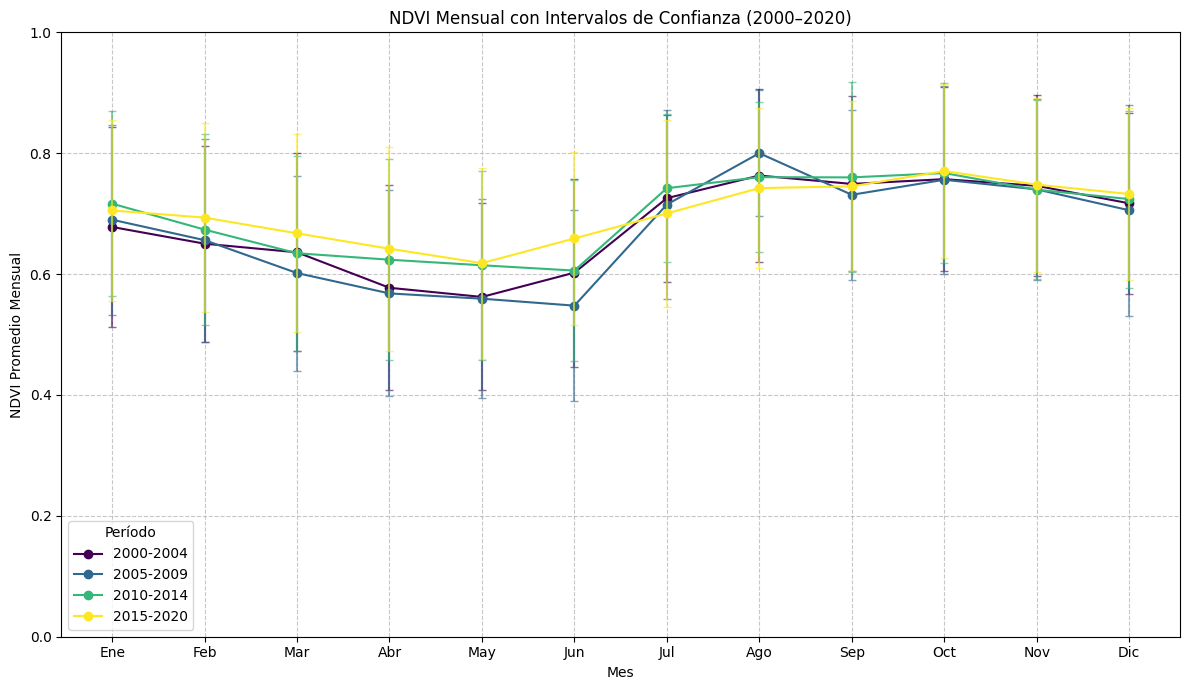

In [46]:
df_mensual_1 = extraer_datos_mensuales(region, periods)
print(df_mensual_1)

df_mensual_ic_1 = calcular_intervalos_confianza(df_mensual_1)
graficar_ndvi_mensual(df_mensual_ic_1, periods)

Periodo de 2000-01-01 hasta 2004-12-31
  Imágenes Landsat 5: 32
  Imágenes Landsat 7: 81
  Imágenes Landsat 8: 0
    Sin imágenes L8
Mes: 1
Mes: 2
Mes: 3
Mes: 4
Mes: 5
Mes: 6
Mes: 7
Mes: 8
Mes: 9
Mes: 10
Mes: 11
Mes: 12
Periodo de 2005-01-01 hasta 2009-12-31
  Imágenes Landsat 5: 2
  Imágenes Landsat 7: 109
  Imágenes Landsat 8: 0
    Sin imágenes L8
Mes: 1
Mes: 2
Mes: 3
Mes: 4
Mes: 5
Mes: 6
Mes: 7
Mes: 8
Mes: 9
Mes: 10
Mes: 11
Mes: 12
Periodo de 2010-01-01 hasta 2014-12-31
  Imágenes Landsat 5: 8
  Imágenes Landsat 7: 115
  Imágenes Landsat 8: 23
Mes: 1
Mes: 2


Mes: 3
Mes: 4
Mes: 5
Mes: 6
Mes: 7
Mes: 8
Mes: 9
Mes: 10
Mes: 11
Mes: 12
Periodo de 2015-01-01 hasta 2020-12-31
  Imágenes Landsat 5: 0
    Sin imágenes L5
  Imágenes Landsat 7: 157
  Imágenes Landsat 8: 157
Mes: 1
Mes: 2
Mes: 3
Mes: 4
Mes: 5
Mes: 6
Mes: 7
Mes: 8
Mes: 9
Mes: 10
Mes: 11
Mes: 12
       period  month  mean_ndvi  std_dev_ndvi
0   2000-2004      1   0.684273      0.030354
1   2000-2004      2   0.644716      0.032166
2   2000-2004      3   0.671125      0.035212
3   2000-2004      4   0.637391      0.055051
4   2000-2004      5   0.622528      0.063758
5   2000-2004      6   0.563960      0.163887
6   2000-2004      7   0.710117      0.084764
7   2000-2004      8   0.783754      0.031667
8   2000-2004      9   0.768245      0.033327
9   2000-2004     10   0.754971      0.048794
10  2000-2004     11   0.770410      0.038971
11  2000-2004     12   0.722680      0.057301
12  2005-2009      1   0.716566      0.034517
13  2005-2009      2   0.699124      0.035420
14  2005-2009  

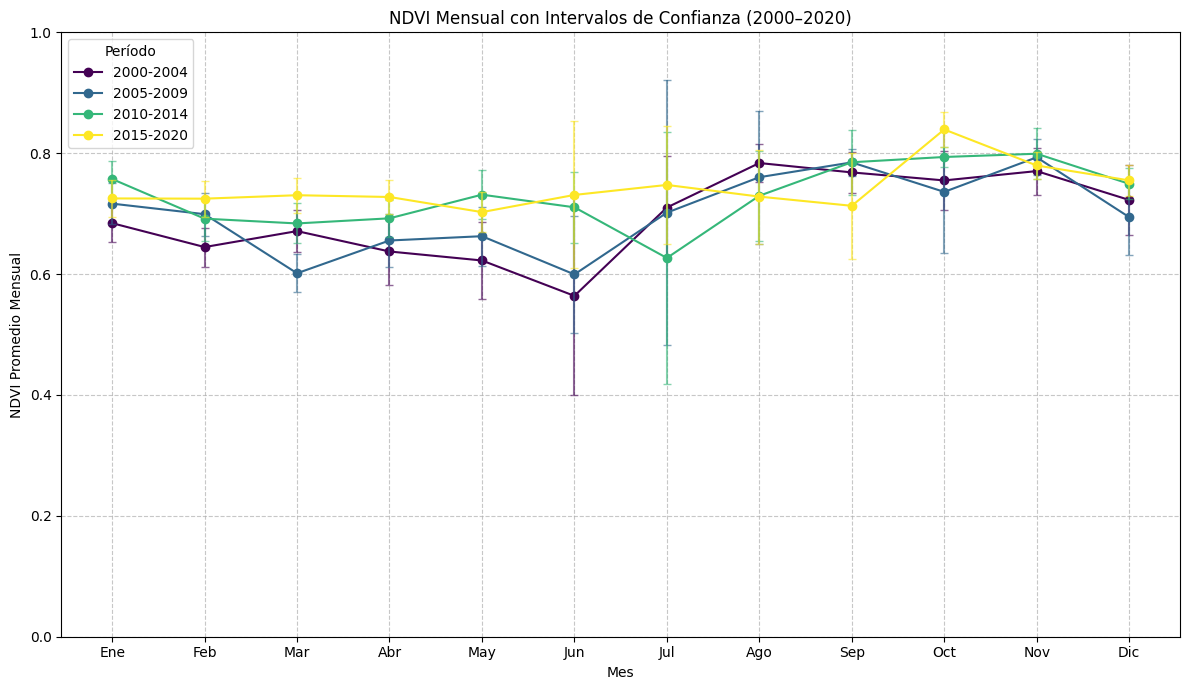

In [47]:
df_mensual_2 = extraer_datos_mensuales(circulo_recortado_ee, periods)
print(df_mensual_2)

df_mensual_ic_2 = calcular_intervalos_confianza(df_mensual_2)
graficar_ndvi_mensual(df_mensual_ic_2, periods)

Representar un mapa interactivo (desabilitar al guardar)

In [ ]:
#  Crear el mapa interactivo
mapa = geemap.Map()
mapa.set_center(centroid.x, centroid.y, ZOOM)

# Agregar área de estudio
mapa.add_gdf(gdf, layer_name=MAP_TITLE, style=STYLE_AREA)

# Agregar rectángulo rojo (bounding box)
mapa.add_gdf(bbox_gdf, layer_name='Bounding box', style=STYLE_BBOX)
print("Representación espacial")
# Mostrar el mapa
mapa